[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/drive/165wzFkFjzpplp30PlhmAkA9R045DWHFH)

# Data
We'll be using the "Index, Violent, Property, and Firearm Rates By County: Beginning 1990" data set available from the Data.Gov website (https://catalog.data.gov/dataset?groups=local&organization_type=State+Government#topic=local_navigation).


In [3]:
!wget https://data.ny.gov/api/views/34dd-6g2j/rows.csv?accessType=DOWNLOAD -nc -O violence_rates.csv

--2018-11-12 19:18:31--  https://data.ny.gov/api/views/34dd-6g2j/rows.csv?accessType=DOWNLOAD
Resolving data.ny.gov (data.ny.gov)... 52.206.140.199, 52.206.68.26, 52.206.140.205
Connecting to data.ny.gov (data.ny.gov)|52.206.140.199|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [text/csv]
Saving to: ‘violence_rates.csv’

violence_rates.csv      [ <=>                ] 103.21K  --.-KB/s    in 0.1s    

Last-modified header invalid -- time-stamp ignored.
2018-11-12 19:18:31 (795 KB/s) - ‘violence_rates.csv’ saved [105687]



In [4]:
import pandas as pd
import numpy as np

df = pd.read_csv('violence_rates.csv')
df.head()

,County,Year,Population,Index Count,Index Rate,Violent Count,Violent Rate,Property Count,Property Rate,Firearm Count,Firearm Rate
0,Albany,1990,292594.0,14418,4927.6,1524,520.9,12894,4406.8,122.0,41.7
1,Allegany,1990,50470.0,1280,2536.2,146,289.3,1134,2246.9,1.0,2.0
2,Bronx,1990,1200900.0,104729,8720.9,33635,2800.8,71094,5920.1,10869.0,905.1
3,Broome,1990,212160.0,7480,3525.6,306,144.2,7174,3381.4,13.0,6.1
4,Cattaraugus,1990,84234.0,2578,3060.5,171,203.0,2407,2857.5,5.0,5.9


**The attributes of interest are 'Violent Count', 'Property Count', and 'Population'**

In [5]:
df.isnull().sum()

County             0
Year               0
Population         0
Index Count        0
Index Rate         0
Violent Count      0
Violent Rate       0
Property Count     0
Property Rate      0
Firearm Count     75
Firearm Rate      75
dtype: int64

In [6]:
df.dropna(axis=1, how='any', inplace=True)
df.isnull().sum()

County            0
Year              0
Population        0
Index Count       0
Index Rate        0
Violent Count     0
Violent Rate      0
Property Count    0
Property Rate     0
dtype: int64

# Violent Count

Let's focus on past 3 decades (>1990) -  and hone in on the following three counties: Bronx, New York and Queens

In [7]:
data = df[(df['County'].isin(['Bronx', 'New York', 'Queens'])) & (df['Year']>=1990)]
print(data.shape)
data.head()

(84, 9)


,County,Year,Population,Index Count,Index Rate,Violent Count,Violent Rate,Property Count,Property Rate
2,Bronx,1990,1200900.0,104729,8720.9,33635,2800.8,71094,5920.1
30,New York,1990,1486480.0,217786,14651.1,44434,2989.2,173352,11661.9
40,Queens,1990,1955125.0,165179,8448.5,30441,1557.0,134738,6891.5
64,Bronx,1991,1205404.0,100071,8301.9,33515,2780.4,66556,5521.5
92,New York,1991,1492055.0,209177,14019.4,41209,2761.9,167968,11257.5


In [8]:
data.tail()

,County,Year,Population,Index Count,Index Rate,Violent Count,Violent Rate,Property Count,Property Rate
1642,New York,2016,1647694.0,46653,2831.4,8839,536.4,37814,2295.0
1652,Queens,2016,2343667.0,33800,1442.2,9356,399.2,24444,1043.0
1676,Bronx,2017,1470074.0,35507,2415.3,12534,852.6,22973,1562.7
1704,New York,2017,1663498.0,47146,2834.1,8671,521.3,38475,2312.9
1714,Queens,2017,2356841.0,32860,1394.2,9184,389.7,23676,1004.6


# Visualizing 

## Box Plots

/usr/local/lib/python3.6/dist-packages/seaborn/categorical.py:454: FutureWarning: remove_na is deprecated and is a private function. Do not use.
  box_data = remove_na(group_data)


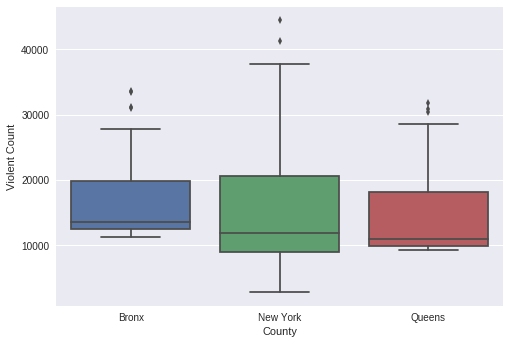

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots()
sns.boxplot(x='County', y='Violent Count', data=data);

**Observation:**

1.   From the BoxPlot, it is evident that the median of 'Voilent Count' is highest in Bronx, followed by New York and then by Queens 
2.   All 3 counties have experienced years where the 'Violent Count' has exceeded the norm – resulting in outliers 
3.   Another interesting thing to note is that the variance (spread of data) in 'Violent Count' shown by New York is substantially more than the other 2 counties



Let's validate the point3 above

In [13]:
comparison = pd.DataFrame()
comparison['county'] = pd.Series(['All 3', 'Bronx', 'New York', 'Queens'])
comparison['std'] = [data['Violent Count'].std(), 
                   data[data['County'] == 'Bronx']['Violent Count'].std(), 
                   data[data['County'] == 'New York']['Violent Count'].std(), 
                   data[data['County'] == 'Queens']['Violent Count'].std()]

comparison

,county,std
0,All 3,8864.217227
1,Bronx,7379.755764
2,New York,11300.048504
3,Queens,7523.768556


## Histograms v/s Bee Swarm Plots

In [0]:
def plot_hist(county, color):
  data[data['County'] == county]['Violent Count'].hist(color=color);  

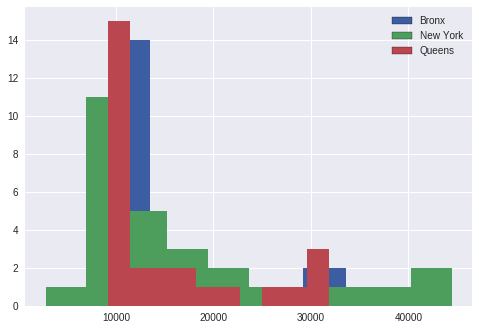

In [30]:
colors = ['#3C5DA1', '#4D9E5C', '#BA474F']
counties = ['Bronx', 'New York', 'Queens']
for ind, each in enumerate(counties):
  plot_hist(each, colors[ind])

from matplotlib.patches import Rectangle
handles = [Rectangle((0,0), 1, 1, color=c, ec="k") for c in colors]
labels= counties
plt.legend(handles, labels);

**Bee Swarm Plots show all the observations under consideration as compared to a Histogram. In a Histogram, the observations (and hence sometimes useful information) are hidden within Bins. Both have their own usage.**

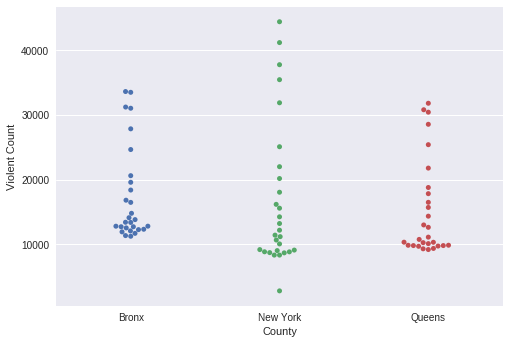

In [33]:
sns.swarmplot(x="County", y="Violent Count", data=data);

**Observation:** Bee Swarm Plot also confirms our earlier observation that spread of the 'Violent Count' is more in New York County as compared to the other 2 counties

# Finding relations/patterns

## 'Violent Count' v/s 'Population'

In [0]:
def find_relation(feature1, feature2):
  data_sub = pd.DataFrame(data, columns=[feature1, feature2])

  sns.set(style='ticks', color_codes=True)
  sns.heatmap(data_sub.astype(float).corr(), 
              linewidths=0.1, 
              square=True, 
              linecolor='white', 
              annot=True)
  plt.show();

  data_sub = pd.DataFrame(data, columns=['County', feature1, feature2])
  data_sub_1 = data_sub[data_sub['County']=='Bronx']
  data_sub_2 = data_sub[data_sub['County']=='New York']
  data_sub_3 = data_sub[data_sub['County']=='Queens']
  plt.plot(data_sub_1[feature2], data_sub_1[feature1], 'ro', label='Bronx')
  plt.plot(data_sub_2[feature2], data_sub_2[feature1], 'go', label='New York')
  plt.plot(data_sub_3[feature2], data_sub_3[feature1], 'bo', label='Queens')
  plt.xlabel(feature2)
  plt.ylabel(feature1)
  plt.legend()
  plt.show();
  
  return data

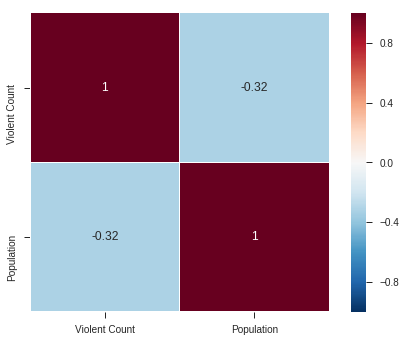

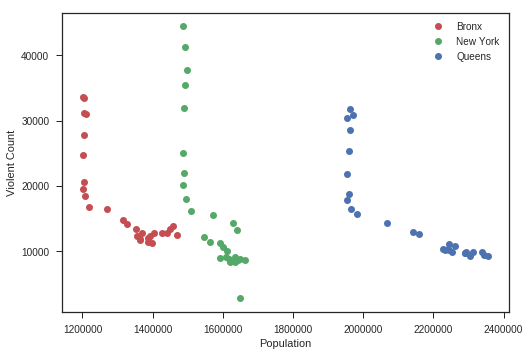

In [38]:
find_relation('Violent Count', 'Population')

**Observation:** Covariance is the measure of how quantities vary together. It is evident from the above Scatter Plot that the 'Violent Count' goes down as the population increases for all 3 counties – i.e. it suggests a negative Covariance

Let's validate the above

In [39]:
data_sub = pd.DataFrame(data, columns=['Violent Count', 'Population'])
data_sub.cov()

,Violent Count,Population
Violent Count,7.857435e+07,-1.035116e+09
Population,-1.035116e+09,1.345770e+11


## 'Violent Count' v/s 'Property Count''

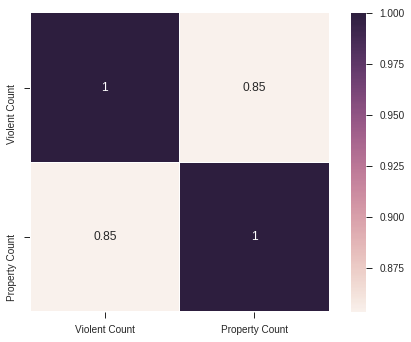

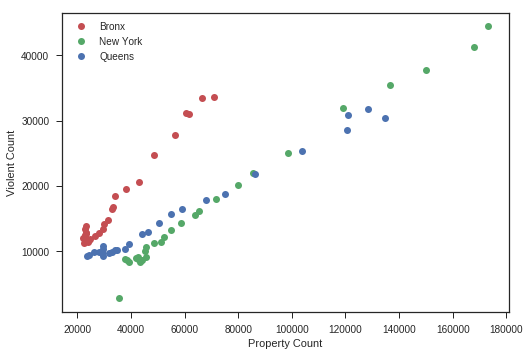

In [40]:
find_relation('Violent Count', 'Property Count')

**Observation:** suggests a positive Covariance

Let's validate the above

In [41]:
data_sub = pd.DataFrame(data, columns=['Violent Count', 'Property Count'])
data_sub.cov()

,Violent Count,Property Count
Violent Count,7.857435e+07,2.679855e+08
Property Count,2.679855e+08,1.254524e+09
